# 01 — Data Collection

NBA team game logs for the **2022-23, 2023-24, and 2024-25** regular seasons — 7,380 rows total.

Data was pulled from the NBA API and saved to `data/cleaned/team_logs_all_seasons.csv`. This notebook explores it.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/cleaned/team_logs_all_seasons.csv', parse_dates=['GAME_DATE'])

print('Shape:', df.shape)
print('Date range:', df['GAME_DATE'].min().date(), 'to', df['GAME_DATE'].max().date())
print('Seasons:', sorted(df['SEASON_ID'].unique()))
df.head()

Shape: (7380, 19)
Date range: 2022-10-18 to 2025-04-13
Seasons: [22022, 22023, 22024]


,SEASON_ID,GAME_ID,GAME_DATE,TEAM_ABBREVIATION,TEAM_NAME,OPPONENT,HOME_AWAY,WL,WIN,PTS,REB,AST,STL,BLK,TOV,FG_PCT,FG3_PCT,FT_PCT,PLUS_MINUS
0,22022,22200005,2022-10-19,ATL,Atlanta Hawks,HOU,Home,W,1,117,38,30,12,5,9,0.500,0.280,0.833,10
1,22022,22200020,2022-10-21,ATL,Atlanta Hawks,ORL,Home,W,1,108,46,26,10,2,17,0.449,0.419,0.938,10
2,22022,22200038,2022-10-23,ATL,Atlanta Hawks,CHA,Home,L,0,109,45,23,8,9,12,0.411,0.229,0.821,-17
3,22022,22200057,2022-10-26,ATL,Atlanta Hawks,DET,Away,W,1,118,46,22,6,12,12,0.495,0.364,0.800,5
4,22022,22200070,2022-10-28,ATL,Atlanta Hawks,DET,Away,W,1,136,45,31,5,8,7,0.567,0.414,0.778,24


In [5]:
# Games per season
df['SEASON_ID'].value_counts().sort_index()

SEASON_ID
22022    2460
22023    2460
22024    2460
Name: count, dtype: int64

In [7]:
# 2024-25 team win percentage summary
recent = df[df['GAME_DATE'] >= '2024-10-01'].copy()

summary = (
    recent.groupby('TEAM_NAME')
    .agg(
        games_played   = ('GAME_ID',    'count'),
        wins           = ('WIN',        'sum'),
        avg_pts        = ('PTS',        'mean'),
        avg_tov        = ('TOV',        'mean'),
        avg_fg_pct     = ('FG_PCT',     'mean'),
        avg_plus_minus = ('PLUS_MINUS', 'mean')
    )
    .assign(win_pct=lambda x: x['wins'] / x['games_played'])
    .sort_values('win_pct', ascending=False)
    .reset_index()
)

print(f'Teams: {len(summary)}')
summary.head(10)

Teams: 30


,TEAM_NAME,games_played,wins,avg_pts,avg_tov,avg_fg_pct,avg_plus_minus,win_pct
0,Oklahoma City Thunder,82,68,120.500000,11.719512,0.482073,12.865854,0.829268
1,Cleveland Cavaliers,82,64,121.939024,13.195122,0.491451,9.536585,0.780488
2,Boston Celtics,82,61,116.268293,11.865854,0.463122,9.109756,0.743902
3,Houston Rockets,82,52,114.292683,13.890244,0.455122,4.512195,0.634146
4,New York Knicks,82,51,115.780488,13.268293,0.486671,4.097561,0.621951
5,LA Clippers,82,50,112.878049,14.878049,0.483098,4.658537,0.609756
6,Denver Nuggets,82,50,120.756098,14.256098,0.507293,3.890244,0.609756
7,Los Angeles Lakers,82,50,113.390244,13.963415,0.479671,1.219512,0.609756
8,Indiana Pacers,82,50,117.365854,13.195122,0.488415,2.231707,0.609756
9,Minnesota Timberwolves,82,49,114.292683,14.463415,0.469915,5.000000,0.597561


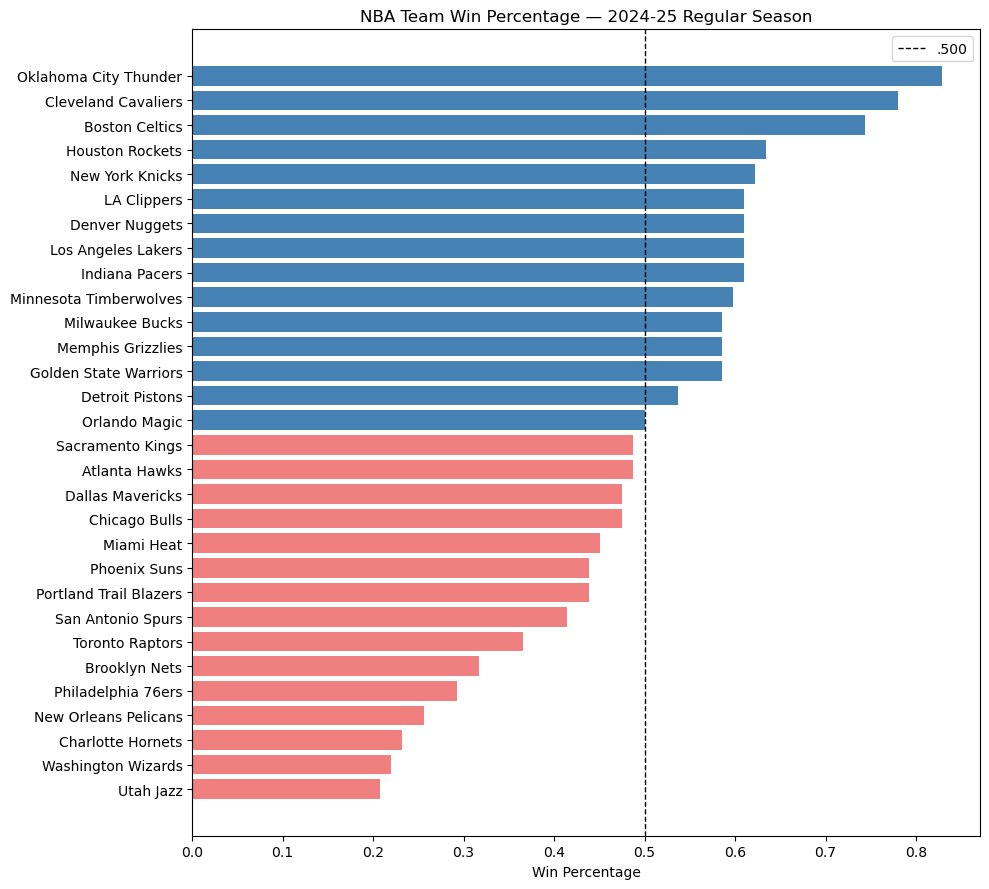

In [9]:
# Bar chart — win percentage by team
plot_data = summary.sort_values('win_pct', ascending=True)

fig, ax = plt.subplots(figsize=(10, 9))
ax.barh(
    plot_data['TEAM_NAME'],
    plot_data['win_pct'],
    color=['steelblue' if w >= 0.5 else 'lightcoral' for w in plot_data['win_pct']]
)
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='.500')
ax.set_xlabel('Win Percentage')
ax.set_title('NBA Team Win Percentage — 2024-25 Regular Season')
ax.legend()
plt.tight_layout()
plt.savefig('../visuals/win_percentage.png', dpi=150)
plt.show()

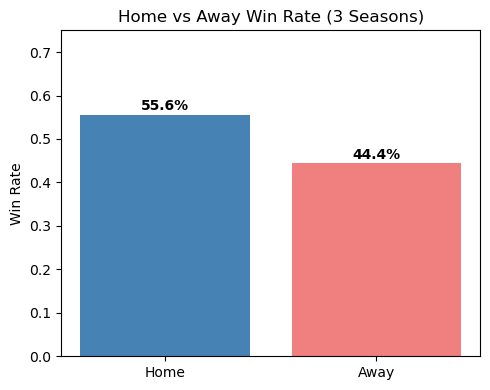

Home win rate: 55.6% | Away win rate: 44.4%


In [11]:
# Home vs Away win rate across all 3 seasons
home_wr = df[df['HOME_AWAY'] == 'Home']['WIN'].mean()
away_wr = df[df['HOME_AWAY'] == 'Away']['WIN'].mean()

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Home', 'Away'], [home_wr, away_wr], color=['steelblue', 'lightcoral'])
ax.set_ylabel('Win Rate')
ax.set_ylim(0, 0.75)
ax.set_title('Home vs Away Win Rate (3 Seasons)')
for i, v in enumerate([home_wr, away_wr]):
    ax.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Home win rate: {home_wr:.1%} | Away win rate: {away_wr:.1%}')